In [28]:
import os

#Numpy is linear algebra lbrary
import numpy as np
# Matplotlib is a visualizations library
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Define device globally
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

### Convolutional and Pooling Layers

Let's first step through the two new layers in Convnets:

* [`nn.Conv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), also known as a convolutional layer.
* [`nn.MaxPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html), also known as a max pooling layer.

> **Question:** What does the "2d" in `nn.Conv2d()` stand for?
>
> The 2d is for 2-dimensional data. As in, our images have two dimensions: height and width. Yes, there's color channel dimension but each of the color channel dimensions have two dimensions too: height and width.
>
> For other dimensional data (such as 1D for text or 3D for 3D objects) there's also `nn.Conv1d()` and `nn.Conv3d()`.

To see some visualization and analyze what is actually happening inside the layers in convnets, you may refer to [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

To test the layers out, let's create some toy data.

In [ ]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(16, 3, 32, 32)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")

Image batch shape: torch.Size([16, 3, 32, 32]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 32, 32]) -> [color_channels, height, width]


Let's create an example `nn.Conv2d()` with various parameters:
* `in_channels` (int) - Number of channels in the input image.
* `out_channels` (int) - Number of channels produced by the convolution.
* `kernel_size` (int or tuple) - Size of the convolving kernel/filter.
* `stride` (int or tuple, optional) - How big of a step the convolving kernel takes at a time. Default: 1.
* `padding` (int, tuple, str) - Padding added to all four sides of input. Default: 0.

![example of going through the different parameters of a Conv2d layer](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-conv2d-layer.gif)

*Example of what happens when you change the hyperparameters of a `nn.Conv2d()` layer.*

In [ ]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here

# Pass the data through the convolutional layer
feature_map = conv_layer(test_image)

In [ ]:
print(feature_map.shape)

torch.Size([10, 30, 30])


Now let's check out what happens when we move data through `nn.MaxPool2d()`.

In [ ]:
# Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPoo2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 32, 32])
Test image with unsqueezed dimension: torch.Size([1, 3, 32, 32])
Shape after going through conv_layer(): torch.Size([1, 10, 30, 30])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 15, 15])


Essentially, **every layer in a neural network is trying to compress data from higher dimensional space to lower dimensional space**.

In other words, take a lot of numbers (raw data) and learn patterns in those numbers, patterns that are predictive whilst also being *smaller* in size than the original values.

From an artificial intelligence perspective, you could consider the whole goal of a neural network to *compress* information.

![each layer of a neural network compresses the original input data into a smaller representation that is (hopefully) capable of making predictions on future input data](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-conv-net-as-compression.png)

This means, that from the point of view of a neural network, intelligence is compression.

This is the idea of the use of a `nn.MaxPool2d()` layer: take the maximum value from a portion of a tensor and disregard the rest.

In essence, lowering the dimensionality of a tensor whilst still retaining a (hopefully) significant portion of the information.

It is the same story for a `nn.Conv2d()` layer.

Except instead of just taking the maximum, the `nn.Conv2d()` performs a convolutional operation on the data (see this in action on the [CNN Explainer webpage](https://poloclub.github.io/cnn-explainer/)).

## Build a Convolutional Network

Develop a Convolutional Neural Network (CNN) with Pytorch.

It is time to apply what we learned about CNNs through an assignment. We will build a fully functional CNN and train it with our familiar CIFAR10 dataset.

The CNN structure will be:

- A conv layer with 3 channels as input, 6 channels as output, and a 5x5 kernel
- A 2x2 max-pooling layer
- A conv layer with 6 channels as input, 16 channels as output, and a 5x5 kernel
- A linear layer with 1655 nodes
- A linear layer with 120 nodes
- A linear layer with 84 nodes
- A linear layer with 10 nodes

Don’t forget to add a Relu layer after each convolutional and linear layer, except the last one because that should output the actual classification.

Finally, let’s use Vanilla SGD once again with a learning rate of 0.001 and a momentum of 0.9, and the cross-entropy loss for our loss function. As you can see in the code, we will train the model in the entire dataset for 10 epoch.

You will need to write code in 5 different places:

1. Define the layers in the CNN __init__.
2. Stack the layers in forward.
3. Define the loss and optimizer in train.
4. Get the Cifar10 image and label, inside the for-loop in train.
5. Run the forward and backward pass.

### Build and train a CNN

The below code should seem familiar to you as it's very similar with the one we used when training a feedforward network. The difference is that this time we have a CNN.

Once again, we will import all the necessary libraries along with our CIFAR10 dataset. The images will be transformed to tensors and will be normalized.

In [2]:
class FashionMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root='./data', train=True, transform=None, download=True):
        self.data = torchvision.datasets.FashionMNIST(root=root, train=train, download=download, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]  # Returns (image, label) tuple

def get_dataloader(batch_size=4, num_workers=0, root='./data'):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)) # FashionMNIST is grayscale, so single channel normalization
    ])

    train_dataset = FashionMNISTDataset(root=root, train=True, transform=transform)
    test_dataset = FashionMNISTDataset(root=root, train=False, transform=transform)

    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_dataloader, test_dataloader

# Get dataloaders
train_dataloader, test_dataloader = get_dataloader(batch_size=16, num_workers=0)

# Define class names for FashionMNIST
class_names = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

batch_size = 16

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.85MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 158kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.3MB/s]


In [4]:
train_data_size = len(train_dataloader.dataset)
test_data_size = len(test_dataloader.dataset)

print(train_data_size)
print(test_data_size)

60000
10000


## Define a CNN
Here you will come into play. Try to define the necessary layers and build the forward pass of our model. Remember that the model's structure is:

- A conv layer with 3 channels as input, 6 channels as output, and a 5x5 kernel
- A 2x2 max-pooling layer
- A conv layer with 6 channels as input, 16 channels as output, and a 5x5 kernel
- A linear layer with 1655 nodes
- A linear layer with 120 nodes
- A linear layer with 84 nodes
- A linear layer with 10 nodes

The trickiest part when building CNNs is to find the correct dimensions for each layer. If you managed to use the correct arguments in the Conv2d layers, you will be ok. Also play close attention to first Linear layer. How will you be able to pass the feature map?

## Solution

In [12]:
#1. DEFINE THE CNN
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # FashionMNIST images are 1 channel, so in_channels should be 1 because nn.Conv2d(input channel, output channel, kernel size)
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # The input features for the first linear layer will change due to input channel change
        # Original: 32x32 image -> conv1 (3->6, 5x5) -> 28x28 -> pool (2x2) -> 14x14
        #           -> conv2 (6->16, 5x5) -> 10x10 -> pool (2x2) -> 5x5
        # So, 16 * 5 * 5 = 400
        # For FashionMNIST (28x28): conv1 (1->6, 5x5) -> 24x24 -> pool (2x2) -> 12x12
        #                           -> conv2 (6->16, 5x5) -> 8x8 -> pool (2x2) -> 4x4
        # So, 16 * 4 * 4 = 256
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4) # Adjust the flattening size
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [29]:
model = CNN() # need to instantiate the network to be used in instance method

# 2. LOSS AND OPTIMIZER
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 3. move the model to GPU (using the globally defined device)
model.to(device)

CNN(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)

In [8]:
# Check the model parameters and architecture
!pip install torchsummary

from torchsummary import summary

summary(model, input_size=(1, 28, 28))  # Changed to 1 channel, 28x28 for FashionMNIST

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
              ReLU-2            [-1, 6, 24, 24]               0
         MaxPool2d-3            [-1, 6, 12, 12]               0
            Conv2d-4             [-1, 16, 8, 8]           2,416
              ReLU-5             [-1, 16, 8, 8]               0
         MaxPool2d-6             [-1, 16, 4, 4]               0
            Linear-7                  [-1, 120]          30,840
              ReLU-8                  [-1, 120]               0
            Linear-9                   [-1, 84]          10,164
             ReLU-10                   [-1, 84]               0
           Linear-11                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

In [9]:
import time
from tqdm.auto import tqdm

# Train in one epoch function
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_correct = 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predictions = torch.max(outputs, 1)
        train_correct += torch.sum(predictions == labels.data)

    return train_loss / len(train_loader.dataset), train_correct.double() / len(train_loader.dataset)

# Validation function
def validate(model, val_loader, loss_fn, device):
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predictions = torch.max(outputs, 1)
            val_correct += torch.sum(predictions == labels.data)

    return val_loss / len(val_loader.dataset), val_correct.double() / len(val_loader.dataset)

# Training and validation loop with timing
def train_and_validate(model, train_loader, val_loader, loss_fn, optimizer, epochs, device='cuda'):
    model.to(device)
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }

    for epoch in tqdm(range(epochs), desc="Training Progress", leave=True):
        epoch_start_time = time.time()

        train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_accuracy = validate(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy.item())
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy.item())

        epoch_end_time = time.time()

        # Use tqdm.write() instead of print() to avoid extra blank lines
        tqdm.write(f'Epoch {epoch+1}/{epochs}: Train loss: {train_loss:.4f}, Train accuracy: {train_accuracy:.4f}, '
                   f'Val loss: {val_loss:.4f}, Val accuracy: {val_accuracy:.4f}, '
                   f'Time: {(epoch_end_time - epoch_start_time):.2f}s')

    return model, history


In [ ]:
# 4. Train the model for 10 epochs

num_epochs =10
trained_model, history = train_and_validate(model, train_dataloader, test_dataloader, loss_fn, optimizer, num_epochs, device)

Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10: Train loss: 0.9478, Train accuracy: 0.6480, Val loss: 0.5875, Val accuracy: 0.7773, Time: 24.93s
Epoch 2/10: Train loss: 0.4945, Train accuracy: 0.8159, Val loss: 0.4838, Val accuracy: 0.8185, Time: 25.00s
Epoch 3/10: Train loss: 0.4170, Train accuracy: 0.8467, Val loss: 0.4167, Val accuracy: 0.8492, Time: 24.48s


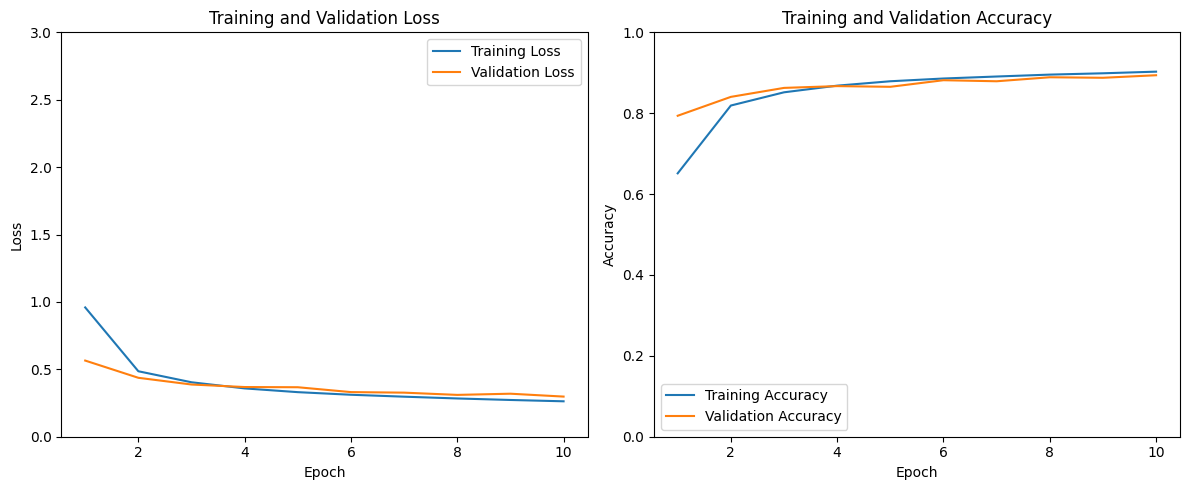

In [11]:
# Extracting data for plotting
train_losses = history['train_loss']
train_accuracies = history['train_accuracy']
val_losses = history['val_loss']
val_accuracies = history['val_accuracy']
epochs = range(1, len(train_losses) + 1)

# Plotting
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylim(0, 3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### [UPDATED] Feature Map Visualization

A **feature map** is the output of a convolutional layer — it shows what patterns the filter detected at each spatial location.

Visualizing feature maps helps answer:
- Is the first layer detecting edges? (yes — it always does)
- Are deeper layers detecting higher-level shapes?
- Is the model actually looking at the right region?

```
Input Image → Conv1 → Feature Maps (6 channels) → Conv2 → Feature Maps (16 channels) → ...
```

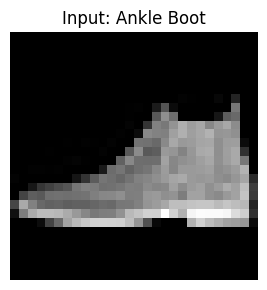

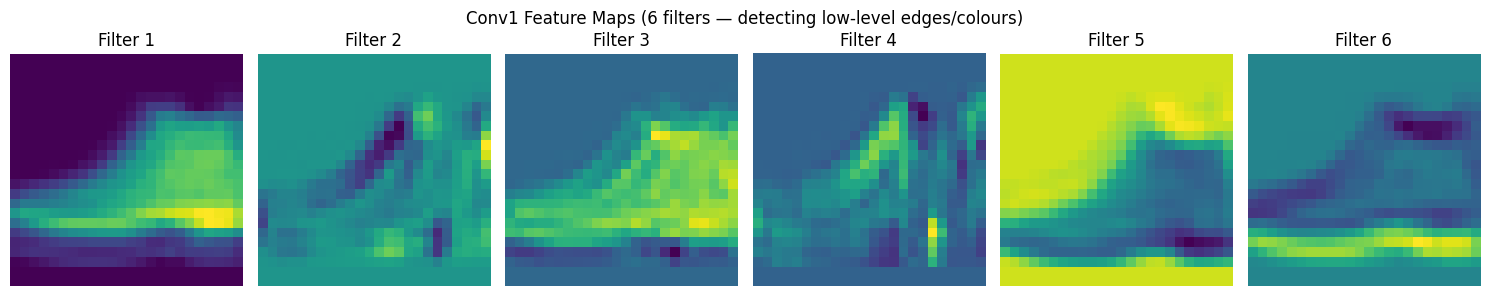

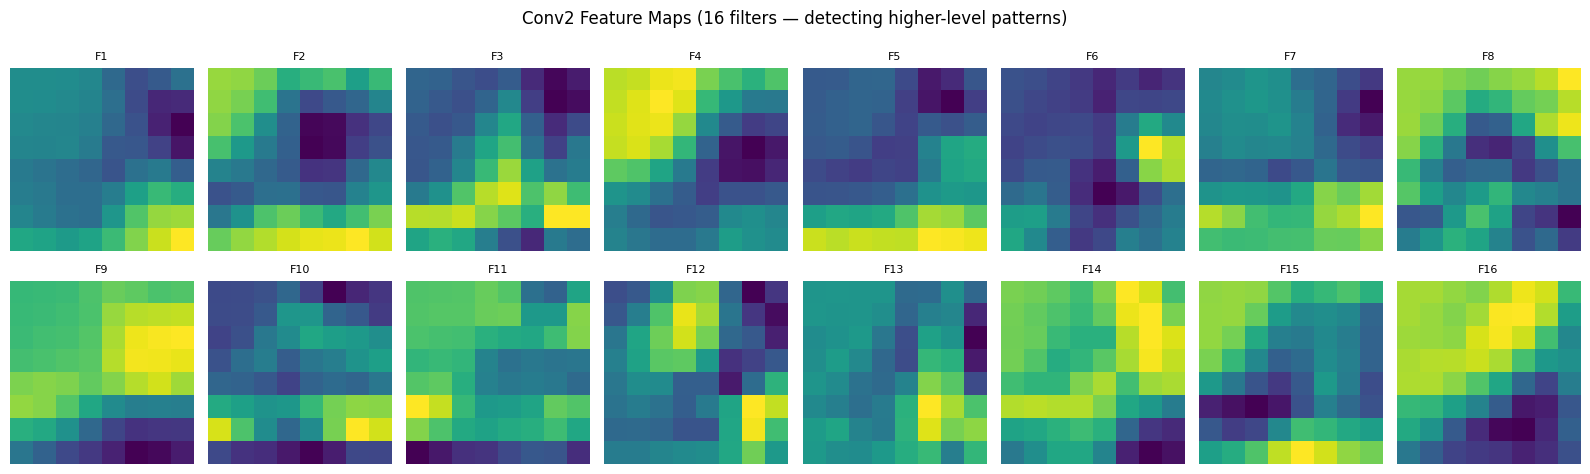

Observation: Early filters detect edges/colours. Deeper filters detect shapes/textures.


In [23]:
# [UPDATED] Feature Map Visualization
import torch
import matplotlib.pyplot as plt
import torchvision

torch.manual_seed(42)

# Get one batch from test loader and pick the first image
dataiter = iter(test_dataloader)
images, labels = next(dataiter)
sample_img = images[0:1].to(device)   # shape: [1, 1, 28, 28] for FashionMNIST

# Ensure the trained model is on the correct device for inference
trained_model.to(device)
trained_model.eval()

# Hook to capture intermediate activations
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks on conv layers
trained_model.conv1.register_forward_hook(get_activation('conv1'))
trained_model.conv2.register_forward_hook(get_activation('conv2'))

with torch.no_grad():
    _ = trained_model(sample_img)

# Plot original image
fig, axes = plt.subplots(1, 1, figsize=(3, 3))
img_show = sample_img.squeeze(0).cpu().permute(1, 2, 0)
# FashionMNIST is grayscale, so handle the single channel for display
if img_show.shape[2] == 1:
    img_show = img_show.squeeze(2)
img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
axes.imshow(img_show, cmap='gray'); axes.axis('off') # Use cmap='gray' for grayscale images
axes.set_title(f'Input: {class_names[labels[0]]}', fontsize=12)
plt.tight_layout(); plt.show()

# Plot conv1 feature maps (6 filters)
fmaps1 = activations['conv1'].squeeze(0).cpu()  # [6, H, W]
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
fig.suptitle('Conv1 Feature Maps (6 filters — detecting low-level edges/colours)', fontsize=12)
for i, ax in enumerate(axes):
    ax.imshow(fmaps1[i], cmap='viridis')
    ax.set_title(f'Filter {i+1}'); ax.axis('off')
plt.tight_layout(); plt.show()

# Plot conv2 feature maps (first 16 filters)
fmaps2 = activations['conv2'].squeeze(0).cpu()  # [16, H, W]
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Conv2 Feature Maps (16 filters — detecting higher-level patterns)', fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps2[i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()
print("Observation: Early filters detect edges/colours. Deeper filters detect shapes/textures.")

### [UPDATED] Grad-CAM: Class Activation Maps

**Grad-CAM** (Gradient-weighted Class Activation Mapping) answers the question:  
*"Which spatial regions of the image did the model focus on when making this prediction?"*

**How it works:**
1. Run a forward pass → get the predicted class
2. Backpropagate the class score to the **last conv layer**
3. Weight each feature map channel by its gradient (importance)
4. Average → get a heatmap → overlay on original image

This is an essential tool for **model interpretability** and debugging.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


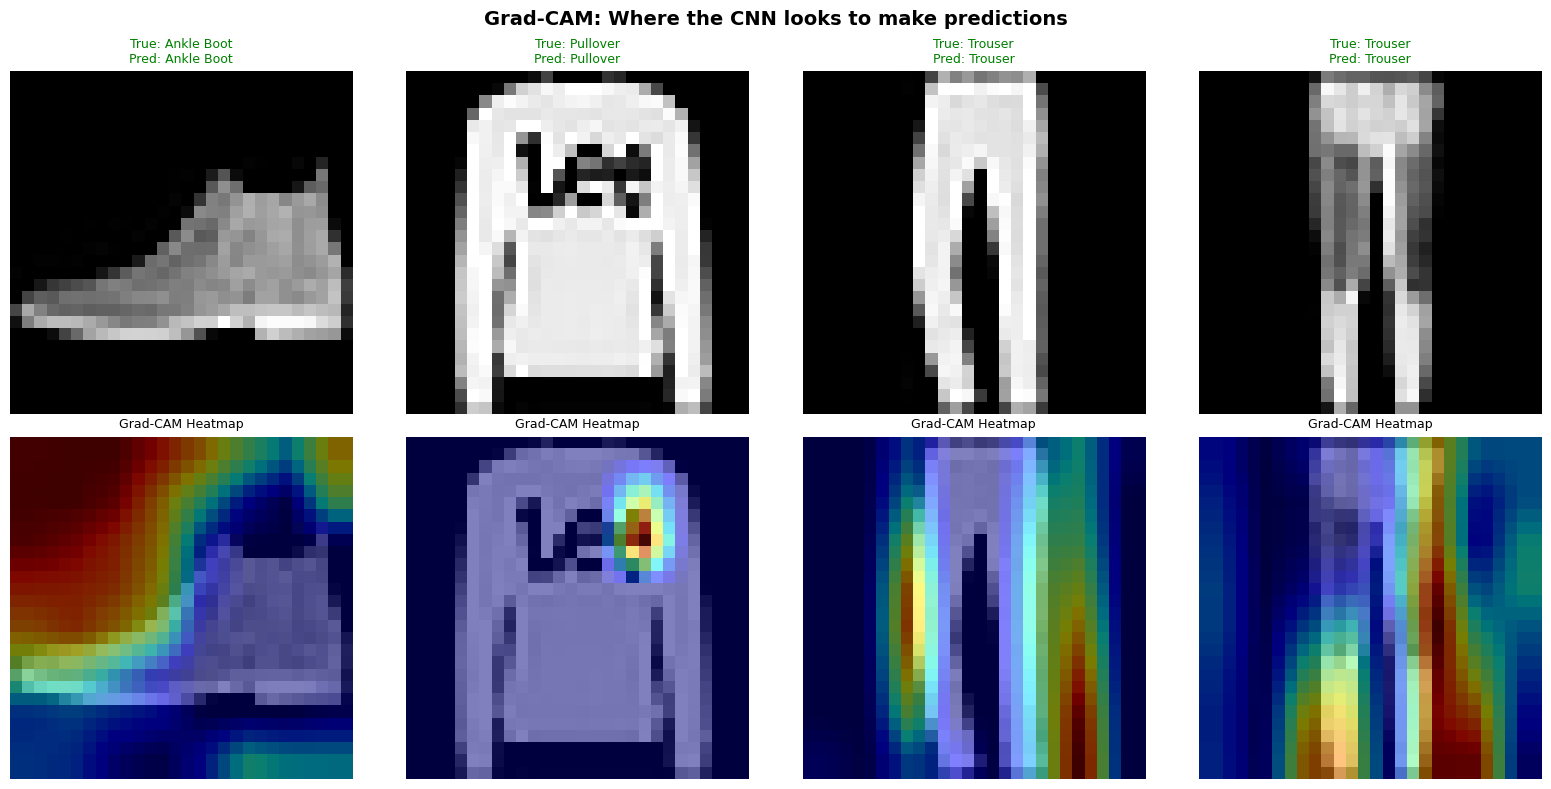

Red/yellow = high attention | Blue = low attention
Correct predictions tend to focus on the object itself.


In [24]:
# [UPDATED] Grad-CAM Implementation
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        self.model.to(input_tensor.device) # Ensure model is on same device as input
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        # Pool gradients over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

# Apply Grad-CAM on 4 test images
grad_cam = GradCAM(trained_model, trained_model.conv2)
dataiter = iter(test_dataloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Grad-CAM: Where the CNN looks to make predictions', fontsize=14, fontweight='bold')

for col in range(4):
    img = images[col:col+1].to(device)
    cam, pred_idx = grad_cam.generate(img)

    # Original image
    raw = images[col].permute(1, 2, 0).numpy()
    # FashionMNIST is grayscale, handle the single channel for display
    if raw.shape[2] == 1:
        raw = raw.squeeze(2)
    raw = (raw - raw.min()) / (raw.max() - raw.min())
    axes[0, col].imshow(raw, cmap='gray') # Use cmap='gray' for grayscale images
    axes[0, col].set_title(f'True: {class_names[labels[col]]}\nPred: {class_names[pred_idx]}',
                           color='green' if labels[col]==pred_idx else 'red', fontsize=9)
    axes[0, col].axis('off')

    # Grad-CAM overlay
    cam_resized = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    # Interpolate to original image size (28x28 for FashionMNIST)
    cam_resized = F.interpolate(cam_resized, size=(28, 28), mode='bilinear', align_corners=False)
    cam_np = cam_resized.squeeze().numpy()
    axes[1, col].imshow(raw, cmap='gray') # Use cmap='gray' for grayscale images
    axes[1, col].imshow(cam_np, cmap='jet', alpha=0.5)
    axes[1, col].set_title('Grad-CAM Heatmap', fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout(); plt.show()
print("Red/yellow = high attention | Blue = low attention")
print("Correct predictions tend to focus on the object itself.")

In [25]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    trained_model.to(device) # Ensure trained_model is on the correct device for inference
    for data in test_dataloader:
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = trained_model(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')

Accuracy of the network on the 10000 test images: 89.39 %


In [26]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in class_names}
total_pred = {classname: 0 for classname in class_names}

# again no gradients needed
with torch.no_grad():
    trained_model.to(device) # Ensure trained_model is on the correct device for inference
    for data in test_dataloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = trained_model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[class_names[label]] += 1
            total_pred[class_names[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:15s} is {accuracy:.1f} %')

Accuracy for class: T-shirt/top     is 81.4 %
Accuracy for class: Trouser         is 97.6 %
Accuracy for class: Pullover        is 83.1 %
Accuracy for class: Dress           is 92.9 %
Accuracy for class: Coat            is 81.4 %
Accuracy for class: Sandal          is 96.3 %
Accuracy for class: Shirt           is 72.5 %
Accuracy for class: Sneaker         is 97.2 %
Accuracy for class: Bag             is 96.4 %
Accuracy for class: Ankle Boot      is 95.1 %


### Confusion Matrix

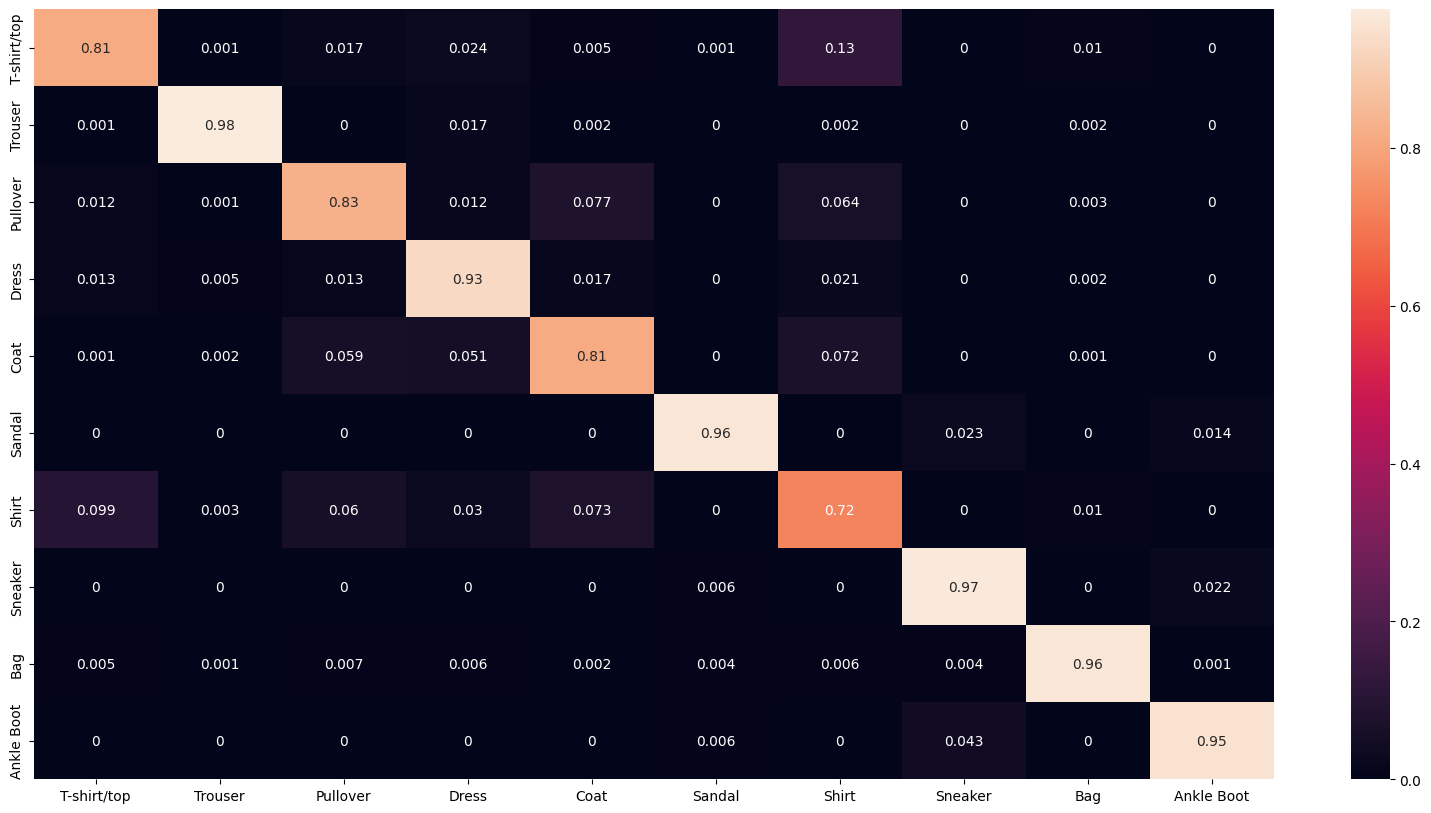

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd

y_pred = []
y_true = []

trained_model.to('cpu') # Move the trained model to CPU for confusion matrix calculation

# iterate over test data
with torch.no_grad(): # No gradients needed for evaluation
    for inputs, labels in test_dataloader:
            inputs = inputs.to('cpu') # Ensure inputs are on CPU as model is on CPU for this section
            output = trained_model(inputs) # Feed Network

            output = (torch.max(torch.exp(output), 1)[1]).data.cpu().numpy()
            y_pred.extend(output) # Save Prediction

            labels = labels.data.cpu().numpy()
            y_true.extend(labels) # Save Truth

# constant for classes
# class_names are already defined for FashionMNIST

# Build confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix/np.sum(cf_matrix) *10, index = [i for i in class_names],
                     columns = [i for i in class_names])
plt.figure(figsize = (20,10))
sn.heatmap(df_cm, annot=True)
plt.show() # Added plt.show() to display the plot